# Phase 3 — Features

Three features are derived from the cleaned laps: which set of tires the car is on, how old
that set is, and a squared term to let degradation curve.

A fourth was planned and is deliberately **not** included. Working out why is the most
useful thing in this phase.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

from cleaning import clean
from data_loader import load_pit_stops
from dataset import build_lap_table
from features import add_features, check_tire_age_resets, verify_fuel_collinearity

race, selected, laps = build_lap_table()
stops = load_pit_stops()
stops = stops[stops["raceId"] == race["raceId"]]
cleaned, _ = clean(laps, stops)

featured = add_features(cleaned, stops)
print(f"{len(featured)} laps, tire age {featured['tire_age'].min()} to {featured['tire_age'].max()}")

410 laps, tire age 1 to 34


## The fuel proxy that had to be dropped

The plan was to add `fuel_proxy = total_laps - lap`, so the model could tell fuel burn apart
from tire wear. Cars start heavy and get lighter, which makes them faster. Tires get older,
which makes them slower. Two effects pulling opposite ways.

Within a single race that feature is worthless. `total_laps` is constant, so
`total_laps - lap` is an exact linear transform of `lap`.

In [2]:
verify_fuel_collinearity(featured)

,feature_a,feature_b,correlation,verdict
0,lap,fuel_proxy = total_laps - lap,-1.0,"perfectly collinear, fuel_proxy adds no inform..."


A correlation of exactly **-1.000**. The two columns carry identical information. In a linear
model the pair is perfectly collinear and the coefficients stop being identifiable.

The right conclusion is the opposite of adding a feature:

> Within one race, **lap number already is the fuel proxy.** It also absorbs track evolution
> as rubber goes down. Both effects are monotonic in lap number and cannot be separated from
> it without data from more than one race.

This is what makes the comparison in Phase 5 fair. The baseline model has `lap_number`, so it
already controls for fuel burn and track evolution. Any improvement the enhanced model shows
is therefore attributable to the tires, not to a fuel effect the baseline lacked.

## The features that are kept

| Feature | Meaning |
| :-- | :-- |
| `stint_number` | Which set of tires, counting from 1. Teams run different compounds in different stints, so this carries compound information the dataset does not expose directly. |
| `tire_age` | Laps completed on the current set, resetting at each stop. The feature the project exists to test. |
| `tire_age_sq` | Tire age squared. A set loses little early and falls away faster once the surface is gone; a linear term alone cannot bend to that. |

In [3]:
resets = check_tire_age_resets(featured, stops)
print(f"every stint starts at tire_age == 1: {bool((resets['tire_age_at_start'] == 1).all())}")
resets

every stint starts at tire_age == 1: True


,code,stint,first_lap,tire_age_at_start,stint_laps,max_tire_age
0,ALB,2,3,1,17,17
1,ALB,3,22,1,18,18
2,ALB,4,42,1,15,15
3,BOT,1,2,1,12,12
4,BOT,2,16,1,19,19
5,BOT,3,37,1,20,20
6,HAM,1,2,1,22,22
7,HAM,2,26,1,31,31
8,HUL,1,2,1,25,25
9,HUL,2,29,1,10,10


Tire age is 0 on the out-lap and 1 on the lap after. Cleaning removes every out-lap, and
removes lap 1 which is the opening stint's equivalent, so every surviving stint correctly
begins at 1.

Albon has no stint 1. He pitted on lap 2, so his opening stint is lap 1 alone and cleaning
removes it. He contributes stints 2 to 4. That is the data behaving correctly, not a bug.

## Does tire age actually show up?

Before modelling anything, the effect should be visible. Each stint is plotted against tire
age rather than lap number, which stacks every stint on a common x-axis.

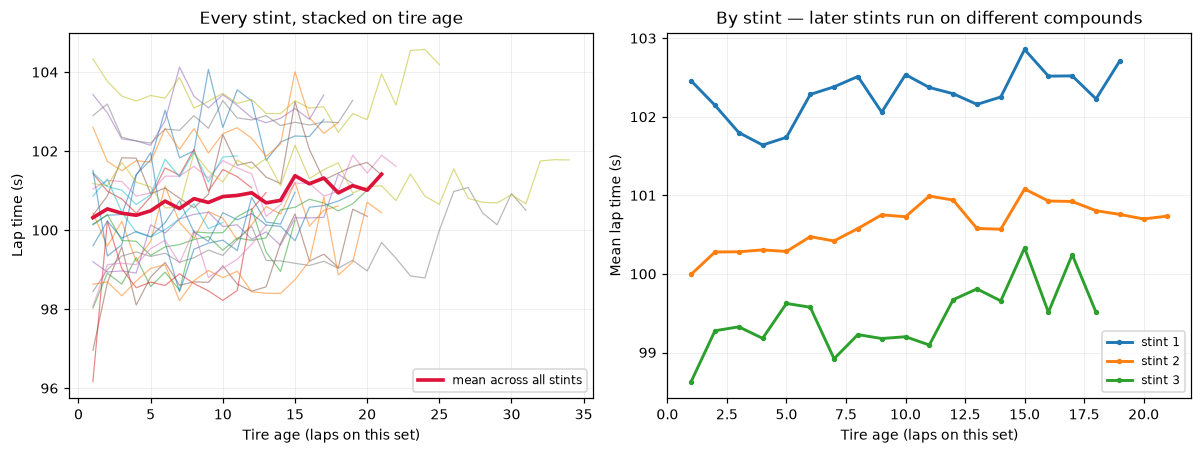

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for (code, stint), grp in featured.groupby(["code", "stint_number"]):
    grp = grp.sort_values("tire_age")
    ax1.plot(grp["tire_age"], grp["seconds"], lw=0.8, alpha=0.55)

binned = featured.groupby("tire_age")["seconds"].agg(["mean", "count"])
solid = binned[binned["count"] >= 5]
ax1.plot(solid.index, solid["mean"], color="crimson", lw=2.4,
         label="mean across all stints", zorder=6)
ax1.set_xlabel("Tire age (laps on this set)")
ax1.set_ylabel("Lap time (s)")
ax1.set_title("Every stint, stacked on tire age")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25, lw=0.5)

for stint, grp in featured.groupby("stint_number"):
    b = grp.groupby("tire_age")["seconds"].agg(["mean", "count"])
    b = b[b["count"] >= 3]
    if len(b) < 3:
        continue  # only one driver ran a 4th stint; too thin to average
    ax2.plot(b.index, b["mean"], lw=1.9, marker="o", ms=2.5, label=f"stint {stint}")
ax2.set_xlabel("Tire age (laps on this set)")
ax2.set_ylabel("Mean lap time (s)")
ax2.set_title("By stint — later stints run on different compounds")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25, lw=0.5)

fig.tight_layout()
fig.savefig(ROOT / "figures" / "03_degradation_by_tire_age.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
corr = featured[["seconds", "lap", "tire_age", "tire_age_sq", "stint_number", "grid"]].corr()
corr[["seconds"]].drop(index="seconds").rename(columns={"seconds": "corr with lap time"}).round(3)

,corr with lap time
lap,-0.623
tire_age,0.172
tire_age_sq,0.144
stint_number,-0.724
grid,0.467


`lap` correlates negatively with lap time, which is fuel burn and track evolution making the
cars faster as the race goes on. `tire_age` correlates positively, which is degradation making
them slower. The two effects fight each other, which is exactly why the baseline needs
`lap_number` for the comparison to mean anything.

In [6]:
featured.to_csv(ROOT / "results" / "laps_featured.csv", index=False)
verify_fuel_collinearity(featured).to_csv(ROOT / "results" / "fuel_collinearity.csv", index=False)
print(f"saved {len(featured)} rows to results/laps_featured.csv")
featured[["code", "lap", "seconds", "stint_number", "tire_age", "tire_age_sq", "grid"]].head()

saved 410 rows to results/laps_featured.csv


,code,lap,seconds,stint_number,tire_age,tire_age_sq,grid
0,HAM,2,101.043,1,1,1,5
1,HAM,3,101.259,1,2,4,5
2,HAM,4,101.231,1,3,9,5
3,HAM,5,100.861,1,4,16,5
4,HAM,6,100.945,1,5,25,5


---

**Phase 3 complete.** Three features kept, one dropped for being an exact restatement of a
feature already present. Phase 4 splits the data by stint, and shows what a random split
would have hidden.